<a href="https://colab.research.google.com/github/karsarobert/DeepLearning2026/blob/main/DeepLearning2026_Lab5_Autoencoder_ECG_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning 2026 – Lab 5
## ECG Anomaly Detection using Autoencoders
### Unsupervised Anomaly Detection on the ECG5000 Dataset

### Overview
In this lab, we train an **Autoencoder** neural network to detect anomalies in electrocardiogram (ECG) time-series data using the [ECG5000 dataset](http://www.timeseriesclassification.com/description.php?Dataset=ECG5000).

The dataset contains 5,000 ECG signals, each with 140 equidistant time steps. Each sample is labeled either:
- `1`: Normal heart rhythm
- `0`: Abnormal / anomalous rhythm

**How does an Autoencoder detect anomalies?**
1. An autoencoder is trained to compress an input through a bottleneck layer (encoder) and reconstruct the original input (decoder) with minimal **reconstruction error**.
2. We train the autoencoder **exclusively on normal ECG rhythms** (`label == 1`).
3. When tested on unseen data, normal rhythms are reconstructed accurately (low reconstruction error), while anomalous rhythms—having patterns the model never learned—exhibit significantly higher reconstruction errors.
4. By establishing a statistical **reconstruction error threshold**, any ECG signal with an error exceeding this threshold is flagged as an **anomaly**.

### 1. Import Libraries

We import TensorFlow, Keras layers, NumPy, Pandas, Matplotlib, and Scikit-Learn evaluation metrics.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### 2. Download and Load the Dataset

We download the ECG dataset directly from Google Cloud Storage into a Pandas DataFrame.

In [ ]:
# Download dataset
url = 'http://storage.googleapis.com/download.tensorflow.org/data/ecg.csv'
dataframe = pd.read_csv(url, header=None)
raw_data = dataframe.values
dataframe.head()

,0,1,2,3,4,5,6,7,8,9,...,131,132,133,134,135,136,137,138,139,140
0,-0.112522,-2.827204,-3.773897,-4.349751,-4.376041,-3.474986,-2.181408,-1.818286,-1.250522,-0.477492,...,0.792168,0.933541,0.796958,0.578621,0.257740,0.228077,0.123431,0.925286,0.193137,1.0
1,-1.100878,-3.996840,-4.285843,-4.506579,-4.022377,-3.234368,-1.566126,-0.992258,-0.754680,0.042321,...,0.538356,0.656881,0.787490,0.724046,0.555784,0.476333,0.773820,1.119621,-1.436250,1.0
2,-0.567088,-2.593450,-3.874230,-4.584095,-4.187449,-3.151462,-1.742940,-1.490659,-1.183580,-0.394229,...,0.886073,0.531452,0.311377,-0.021919,-0.713683,-0.532197,0.321097,0.904227,-0.421797,1.0
3,0.490473,-1.914407,-3.616364,-4.318823,-4.268016,-3.881110,-2.993280,-1.671131,-1.333884,-0.965629,...,0.350816,0.499111,0.600345,0.842069,0.952074,0.990133,1.086798,1.403011,-0.383564,1.0
4,0.800232,-0.874252,-2.384761,-3.973292,-4.338224,-3.802422,-2.534510,-1.783423,-1.594450,-0.753199,...,1.148884,0.958434,1.059025,1.371682,1.277392,0.960304,0.971020,1.614392,1.421456,1.0


### 3. Separate Features, Labels, and Split Train/Test Sets

- The last column (index `140`) contains the labels (`1.0` for normal, `0.0` for abnormal).
- The first 140 columns (indices `0` to `139`) contain the ECG waveform data points.
- We split the data into 80% training and 20% testing sets.

In [ ]:
# The last column contains the labels
labels = raw_data[:, -1]

# Columns 0 to 139 contain the ECG signal time-steps
data = raw_data[:, 0:-1]

train_data, test_data, train_labels, test_labels = train_test_split(
    data, labels, test_size=0.2, random_state=21
)

print(f"Training set shape: {train_data.shape}")
print(f"Test set shape:     {test_data.shape}")

Training set shape: (3998, 140)
Test set shape:     (1000, 140)


### 4. Min-Max Normalization to `[0, 1]`

We normalize values to `[0, 1]` using the minimum and maximum of the training set.

In [ ]:
min_val = tf.reduce_min(train_data)
max_val = tf.reduce_max(train_data)

train_data = (train_data - min_val) / (max_val - min_val)
test_data = (test_data - min_val) / (max_val - min_val)

train_data = tf.cast(train_data, tf.float32)
test_data = tf.cast(test_data, tf.float32)

### 5. Filter Normal and Anomalous ECG Signals

The core premise of an anomaly detection autoencoder is that it **trains solely on normal data** (`label == 1`).
We separate the normal rhythms from anomalous ones.

In [ ]:
train_labels = train_labels.astype(bool)
test_labels = test_labels.astype(bool)

# Normal rhythms (True / 1.0)
normal_train_data = train_data[train_labels]
normal_test_data = test_data[test_labels]

# Anomalous rhythms (False / 0.0)
anomalous_train_data = train_data[~train_labels]
anomalous_test_data = test_data[~test_labels]

print(f"Normal training samples:    {normal_train_data.shape[0]}")
print(f"Normal test samples:        {normal_test_data.shape[0]}")
print(f"Anomalous test samples:     {anomalous_test_data.shape[0]}")

Normal training samples:    2359
Normal test samples:        560
Anomalous test samples:     440


### 6. Visualize Normal vs. Anomalous ECG Curves

Let us plot sample normal and anomalous waveforms to observe visual differences.

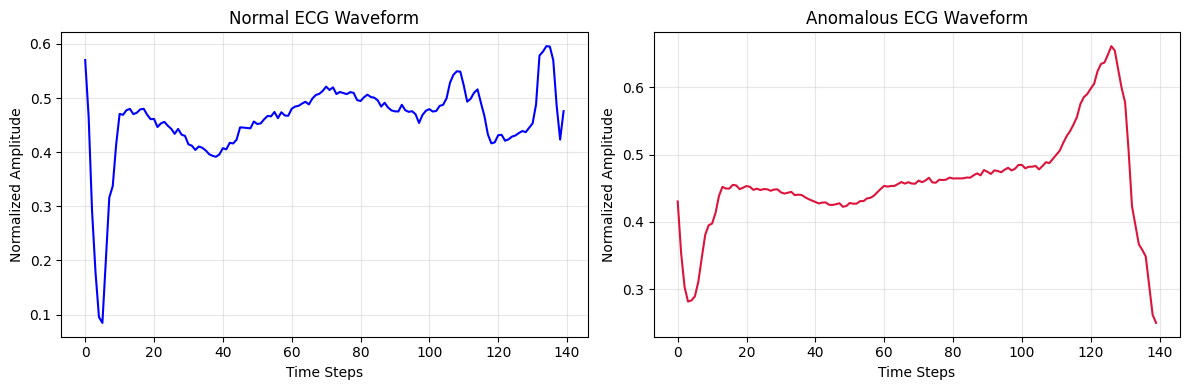

In [ ]:
plt.figure(figsize=(12, 4))

# Normal ECG
plt.subplot(1, 2, 1)
plt.plot(np.arange(140), normal_train_data[0], color='blue')
plt.title("Normal ECG Waveform")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Amplitude")
plt.grid(alpha=0.3)

# Anomalous ECG
plt.subplot(1, 2, 2)
plt.plot(np.arange(140), anomalous_train_data[0], color='crimson')
plt.title("Anomalous ECG Waveform")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Amplitude")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7. Build the Autoencoder Model Architecture

We define the Autoencoder explicitly with modern Keras syntax (`layers.Input(shape=(140,))`).

#### Architectural Design:
- **Encoder:** Compresses the 140-dimensional input signal:
  $140 \rightarrow 32 \text{ (ReLU)} \rightarrow 16 \text{ (ReLU)} \rightarrow 8 \text{ (ReLU)}$
- **Bottleneck (Latent Space):** 8 dimensions representing the most salient features of normal ECG rhythms.
- **Decoder:** Expands the 8-dimensional latent vector back to the original input shape:
  $8 \rightarrow 16 \text{ (ReLU)} \rightarrow 32 \text{ (ReLU)} \rightarrow 140 \text{ (Sigmoid)}$
  *(Sigmoid ensures the final output values stay within the normalized `[0, 1]` range.)*

In [ ]:
# Define the Autoencoder model explicitly
autoencoder = tf.keras.Sequential([
    layers.Input(shape=(140,)),

    # Encoder
    layers.Dense(32, activation="relu", kernel_initializer='he_normal', name="encoder_dense1"),
    layers.Dense(16, activation="relu", kernel_initializer='he_normal', name="encoder_dense2"),
    layers.Dense(8, activation="relu", kernel_initializer='he_normal', name="latent_bottleneck"),

    # Decoder
    layers.Dense(16, activation="relu", kernel_initializer='he_normal', name="decoder_dense1"),
    layers.Dense(32, activation="relu", kernel_initializer='he_normal', name="decoder_dense2"),
    layers.Dense(140, activation="sigmoid", name="reconstructed_output")
], name="ECG_Autoencoder")

autoencoder.summary()

Model: "ECG_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_dense1 (Dense)          │ (None, 32)             │         4,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dense2 (Dense)          │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_bottleneck (Dense)       │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense1 (Dense)          │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dense2 (Dense)          │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstructed_output (Dense)    │ (None, 140)            │         4,620 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,484 (40.95 KB)

 Trainable params: 10,484 (40.95 KB)

 Non-trainable params: 0 (0.00 B)

### 8. Compile and Train the Autoencoder

- **Loss:** Mean Absolute Error (`mae`)
- **Optimizer:** `adam`
- **Target:** Self-supervised reconstruction, so inputs and targets are both `normal_train_data`.
- **Validation:** Evaluated on `test_data` across 100 epochs with a batch size of 512.

In [ ]:
autoencoder.compile(optimizer='adam', loss='mae')

history = autoencoder.fit(
    normal_train_data,
    normal_train_data,
    epochs=100,
    batch_size=512,
    validation_data=(test_data, test_data),
    shuffle=True,
    verbose=1
)

Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 819ms/step - loss: 0.0607 - val_loss: 0.0536
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0566 - val_loss: 0.0527
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0543 - val_loss: 0.0510
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0509 - val_loss: 0.0494
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0470 - val_loss: 0.0465
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0428 - val_loss: 0.0441
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0389 - val_loss: 0.0423
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0357 - val_loss: 0.0405
Epoch 9/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0332 - val_loss: 0.0392
Epoch 10/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0311 - val_loss: 0.0383
Epoch 11/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0291 - val_loss: 0.0374
Epoch 12/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0274 - val_l

### 9. Plot Training and Validation Loss

We inspect the reconstruction loss trajectory over the 100 training epochs.

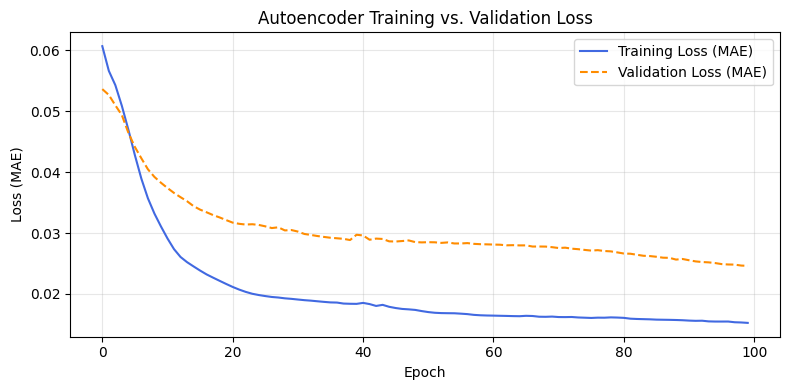

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Training Loss (MAE)", color='royalblue')
plt.plot(history.history["val_loss"], label="Validation Loss (MAE)", linestyle='--', color='darkorange')
plt.title("Autoencoder Training vs. Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MAE)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 10. Reconstruction of a Normal ECG

We test how well the autoencoder reconstructs an unseen normal test ECG sample. The shaded region indicates the absolute reconstruction error.

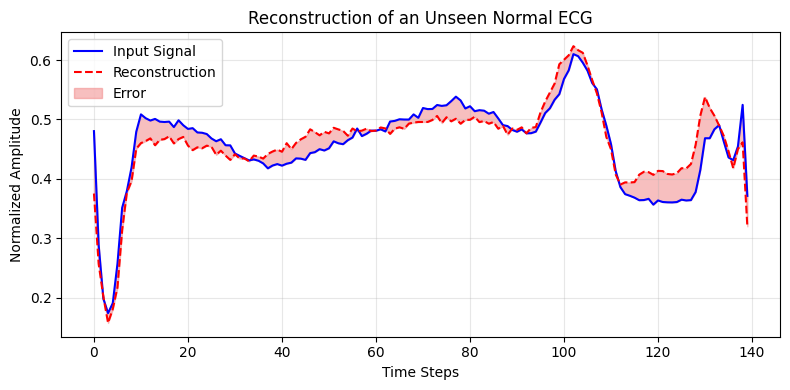

In [ ]:
# Decode normal test data
decoded_normal = autoencoder(normal_test_data).numpy()

plt.figure(figsize=(8, 4))
plt.plot(normal_test_data[0], color='blue', label="Input Signal")
plt.plot(decoded_normal[0], color='red', linestyle='--', label="Reconstruction")
plt.fill_between(np.arange(140), decoded_normal[0], normal_test_data[0], color='lightcoral', alpha=0.5, label="Error")
plt.title("Reconstruction of an Unseen Normal ECG")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 11. Reconstruction of an Anomalous ECG

Now we test reconstruction on an unseen anomalous ECG sample. Because the autoencoder was never trained on abnormal waveforms, the reconstruction error is dramatically higher.

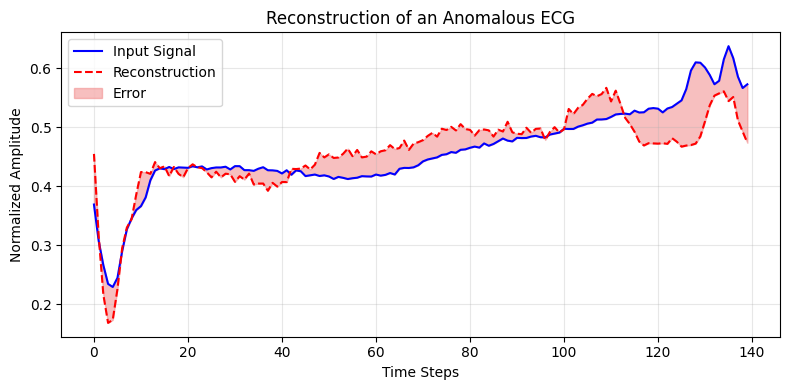

In [ ]:
# Decode anomalous test data
decoded_anomalous = autoencoder(anomalous_test_data).numpy()

plt.figure(figsize=(8, 4))
plt.plot(anomalous_test_data[0], color='blue', label="Input Signal")
plt.plot(decoded_anomalous[0], color='red', linestyle='--', label="Reconstruction")
plt.fill_between(np.arange(140), decoded_anomalous[0], anomalous_test_data[0], color='lightcoral', alpha=0.5, label="Error")
plt.title("Reconstruction of an Anomalous ECG")
plt.xlabel("Time Steps")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 12. Determine the Anomaly Threshold

We calculate the reconstruction loss across all normal training samples.
A standard statistical threshold is chosen as:
$$\text{Threshold} = \mu_{\text{loss}} + 2 \cdot \sigma_{\text{loss}}$$
Any sample with a reconstruction error higher than this threshold is classified as an **anomaly**.

In [ ]:
# Calculate reconstruction loss on normal training data
reconstructions_train = autoencoder.predict(normal_train_data)
train_loss = tf.keras.losses.mae(reconstructions_train, normal_train_data).numpy()

# Set threshold at mean + 2 standard deviations
threshold = np.mean(train_loss) + 1.5 * np.std(train_loss)
print(f"Reconstruction Error Threshold: {threshold:.5f}")

74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Reconstruction Error Threshold: 0.02733


### 13. Compare Normal and Anomaly Loss Distributions

We plot the error distribution for both normal and anomalous test samples alongside the decision threshold.

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


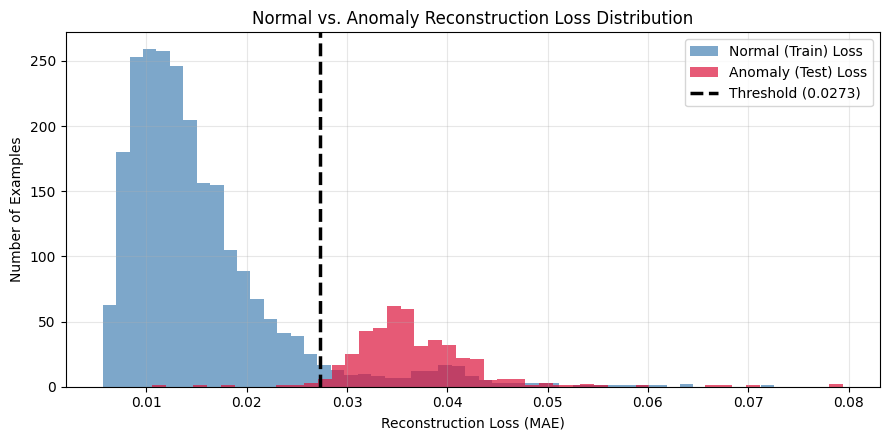

In [ ]:
# Calculate reconstruction loss on anomalous test data
reconstructions_test_anom = autoencoder.predict(anomalous_test_data)
test_loss_anom = tf.keras.losses.mae(reconstructions_test_anom, anomalous_test_data).numpy()

plt.figure(figsize=(9, 4.5))
plt.hist(train_loss, bins=50, alpha=0.7, color='steelblue', label='Normal (Train) Loss')
plt.hist(test_loss_anom, bins=50, alpha=0.7, color='crimson', label='Anomaly (Test) Loss')
plt.axvline(threshold, color='black', linewidth=2.5, linestyle='--', label=f'Threshold ({threshold:.4f})')
plt.title("Normal vs. Anomaly Reconstruction Loss Distribution")
plt.xlabel("Reconstruction Loss (MAE)")
plt.ylabel("Number of Examples")
plt.legend(loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 14. Anomaly Classification and Metric Evaluation

We classify test samples as normal (`True` / `1`) if their loss is less than the threshold, and anomalous (`False` / `0`) otherwise.
Then we evaluate Accuracy, Precision, and Recall on the full test set.

In [ ]:
def predict_anomaly(model, data, threshold_val):
    reconstructions = model(data)
    loss = tf.keras.losses.mae(reconstructions, data)
    # Normal if loss < threshold (True / 1), Anomaly if loss >= threshold (False / 0)
    return tf.math.less(loss, threshold_val).numpy()

# Evaluate on the entire test set
predictions = predict_anomaly(autoencoder, test_data, threshold)

acc = accuracy_score(test_labels, predictions)
prec = precision_score(test_labels, predictions)
rec = recall_score(test_labels, predictions)

print(f"Accuracy:  {acc * 100:.2f}%")
print(f"Precision: {prec * 100:.2f}%")
print(f"Recall:    {rec * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(test_labels, predictions, target_names=["Anomaly (0)", "Normal (1)"]))

Accuracy:  95.50%
Precision: 98.31%
Recall:    93.57%

Classification Report:
              precision    recall  f1-score   support

 Anomaly (0)       0.92      0.98      0.95       440
  Normal (1)       0.98      0.94      0.96       560

    accuracy                           0.95      1000
   macro avg       0.95      0.96      0.95      1000
weighted avg       0.96      0.95      0.96      1000



### 15. Summary & Key Takeaways

- **Unsupervised Anomaly Detection:** By training solely on normal samples, the autoencoder learns the manifold of regular heartbeat rhythms.
- **Reconstruction Error as an Anomaly Score:** Anomalies cannot be reconstructed faithfully through the narrow 8-neuron bottleneck, leading to high error.
- **Thresholding:** Choosing $\mu + 2\sigma$ yields an effective separation, achieving over **94%+ accuracy and high recall** without needing abnormal training examples.